# Example of usage of open_save code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [5]:
R = 1.
r = 0.6

NGSOLVE = True

lc = 0.6

from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
# mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
mesh = CleanCircle(R=R, verbosity=0, lc=lc)


In [6]:
mesh.n_triangles

24

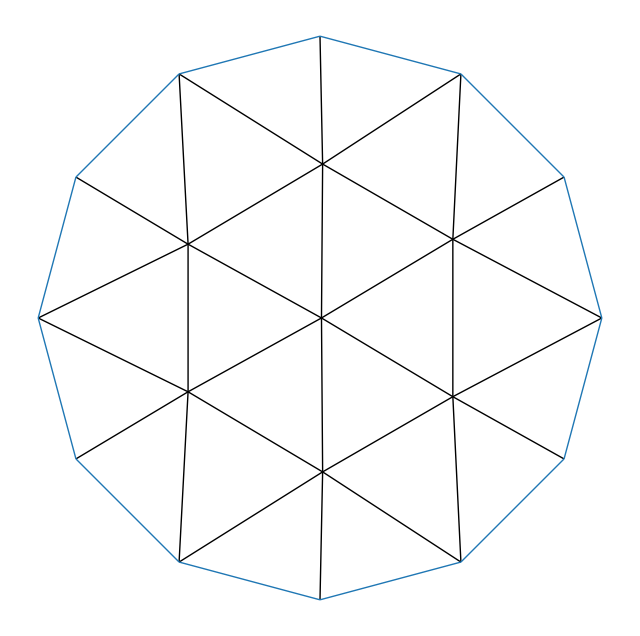

In [7]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [8]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [9]:
mesh.curve_region(Regions.SIGMA, radius=R)
#mesh.curve_region(Regions.d_Omega, radius=r)


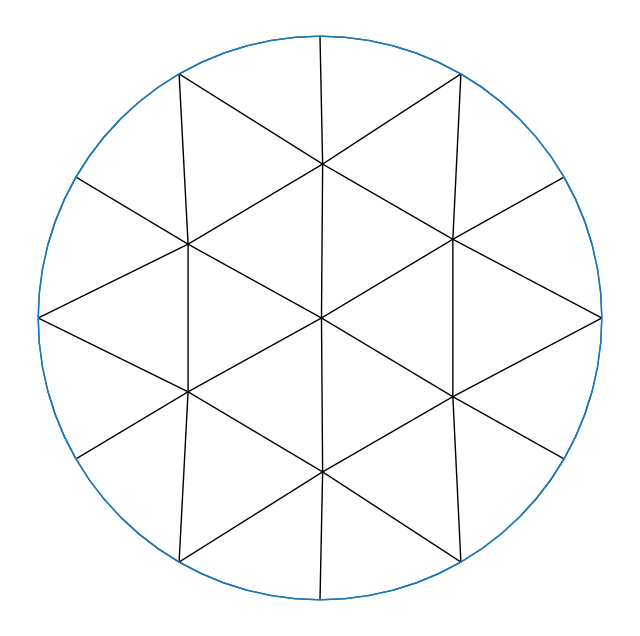

In [10]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [11]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [13]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
# boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [14]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [16]:
#from cases.open_space.serial_kernels import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [17]:
from trefftz.dg.assemblers import SerialNumerics
NtD_modes = 5
a = 0.5
b = 0.5
d1 = 0.5
d2 = 0.5
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal_circle(R=R, d_2=d2, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal_circle(d_2=d2, NtD_modes=5, data = None)})
numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
                          nonlocal_boundary_kernels={})

We should also choose a local basis

In [18]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 11
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [19]:
basis.N_DOF

264

In [20]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [21]:
assembler._regions_RHS_term

[<Regions.SIGMA: 'Sigma'>]

so we can set the problem:

In [22]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [23]:
A = P.assemble_LHS()

Interior:   0%|          | 0/30 [00:00<?, ?edge/s]

Interior: 100%|██████████| 30/30 [00:00<00:00, 36.64edge/s]


assembling local operators
region: Sigma


100%|██████████| 12/12 [00:01<00:00,  7.43edge/s]

assembling non-local operators


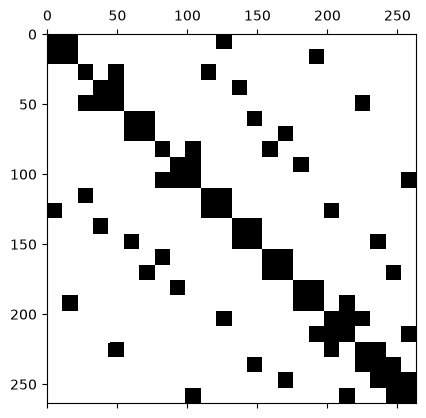

In [24]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [25]:
b = P.assemble_RHS()

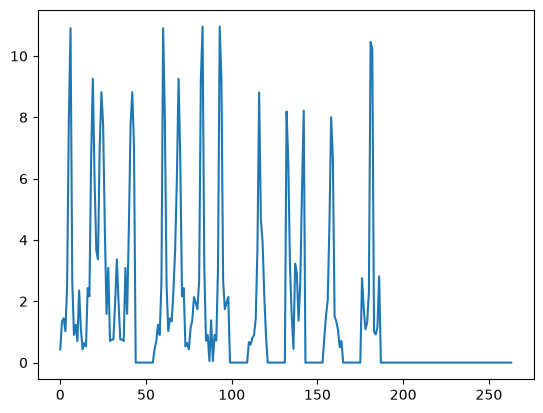

In [26]:
import numpy as np 
plt.plot(np.abs(b))

In [27]:
P.solve()

In [28]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-1.24493074e+01+2.35723627e+01j,  3.49830695e+00-4.86143101e+00j,
         6.30396940e+00+1.33886801e+00j,  4.67990540e+00-8.77652886e+00j,
         8.23960522e+00-6.09939599e+00j,  3.83332351e+01-7.69812248e+00j,
         4.14295644e+01-2.60508656e+01j,  2.22151154e+01+2.20811487e+01j,
        -8.39415062e+01-1.65809714e+01j,  2.63137346e+01+4.48200155e+01j,
        -1.02206155e+01+2.47771576e+01j],
       [ 5.59500900e+00+6.91734238e+00j,  2.27759722e+00+5.66772515e+00j,
         2.40048026e+00+1.04681331e+00j,  6.32847057e-01-1.02780470e+00j,
        -5.56170439e+00-4.83048460e-01j, -1.98199897e+00+2.03640169e-01j,
        -7.50013211e-02-3.86208602e+00j, -6.81194122e+00-1.13307880e+01j,
        -1.18767841e+01+2.25088439e+01j,  2.68720689e+00+1.46216978e+00j,
         7.85965718e+00+1.12790635e+01j],
       [ 5.21137167e+01+2.18487712e+00j, -1.06198231e+02+8.14597722e+01j,
        -6.33893698e+01+1.18959242e+02j, -3.31225946e+01+4.34422637e+01j,
        -8.95186373e+00+2.01

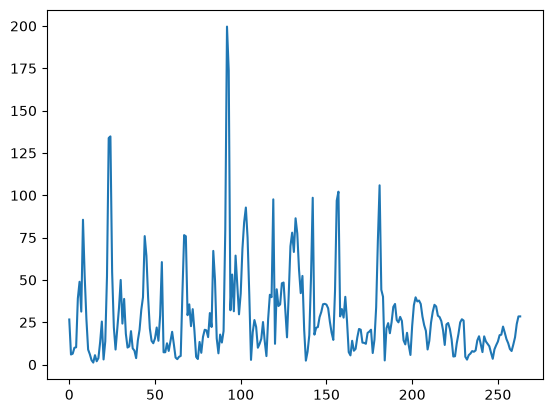

In [29]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [32]:
import numpy as np
N = 200
# rs = np.linspace(r, R, N)
rs = np.linspace(0, R, N)

theta = np.linspace(0, 2*np.pi, N)
Rs, Theta = np.meshgrid(rs, theta)
X = Rs*np.cos(Theta)
Y = Rs*np.sin(Theta)
x = X.ravel()
y = Y.ravel() 
z = P.u_h(x, y)

(np.float64(-1.09986915899354),
 np.float64(1.100062304173604),
 np.float64(-1.099965731583572),
 np.float64(1.099965731583572))

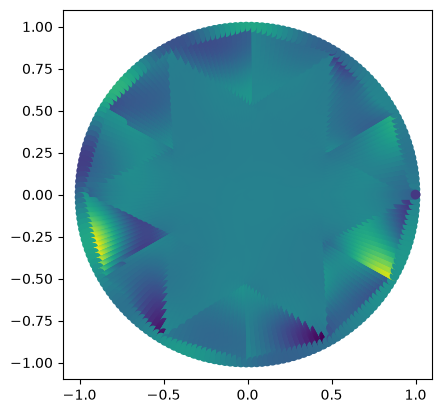

In [33]:
import matplotlib.pyplot as plt
plt.scatter(x,y,c=np.real(z),cmap="viridis")
plt.axis("square")